<a href="https://colab.research.google.com/github/Prabhsimar2104/DL-Project/blob/main/VGGNet16-CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
base_path = "/content/drive/MyDrive/archive/chest_xray"

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report

In [18]:
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1
)

train_data = train_datagen.flow_from_directory(
    base_path + '/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    base_path + '/train',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    base_path + '/test',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 4695 images belonging to 2 classes.
Found 521 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [19]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
for layer in base_model.layers:
    layer.trainable = False

In [21]:
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_vgg16.h5',
    monitor='val_accuracy',
    save_best_only=True
)

In [36]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 138s 937ms/step - accuracy: 0.9395 - loss: 0.1571 - val_accuracy: 0.9443 - val_loss: 0.1442
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 127s 865ms/step - accuracy: 0.9455 - loss: 0.1582 - val_accuracy: 0.9520 - val_loss: 0.1170
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 126s 854ms/step - accuracy: 0.9521 - loss: 0.1285 - val_accuracy: 0.9405 - val_loss: 0.1454
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.9500 - loss: 0.1345

147/147 ━━━━━━━━━━━━━━━━━━━━ 126s 851ms/step - accuracy: 0.9499 - loss: 0.1349 - val_accuracy: 0.9578 - val_loss: 0.1349
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 126s 852ms/step - accuracy: 0.9514 - loss: 0.1376 - val_accuracy: 0.9578 - val_loss: 0.1199


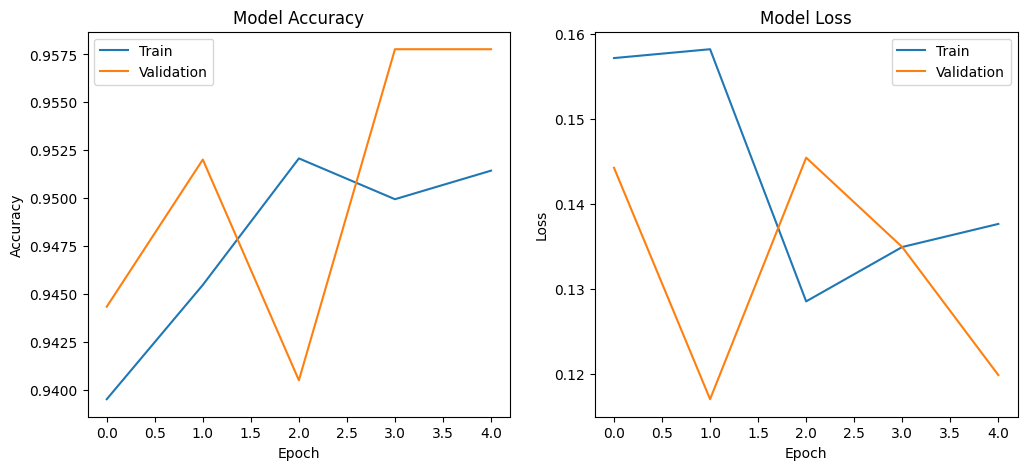

In [37]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [44]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 535ms/step - accuracy: 0.9071 - loss: 0.3083
Test Accuracy: 0.9070512652397156


In [45]:
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int).flatten()
y_true = test_data.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 373ms/step


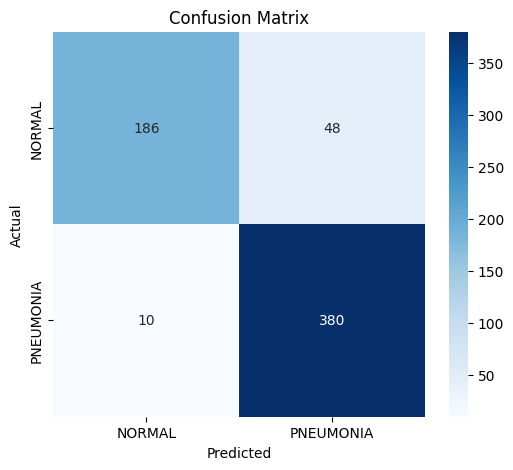

In [46]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','PNEUMONIA'],
            yticklabels=['NORMAL','PNEUMONIA'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [47]:
print(classification_report(y_true, y_pred, target_names=['NORMAL','PNEUMONIA']))

              precision    recall  f1-score   support

      NORMAL       0.95      0.79      0.87       234
   PNEUMONIA       0.89      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.88      0.90       624
weighted avg       0.91      0.91      0.91       624



In [48]:
print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.9070512652397156


In [49]:
model.save('/content/drive/MyDrive/best_vgg16.h5')